<a href="https://colab.research.google.com/github/foudrayelias-ALPHA/Xerxes_p1/blob/main/Xerxes_p1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Xerxes — Philosophy / Religion / Math LLM

**Architecture:** Decoder-only Transformer, ~10M parameters  
**Config:** 6 layers · 512 hidden dim · 8 heads · MHA · RoPE · Pre-RMSNorm · Standard MLP · 512 context  
**Tokenizer:** BPE (trained on your corpus via HuggingFace tokenizers)  
**Storage:** All weights, tokenizer, and data saved to Google Drive
---
**Before running:** Set runtime to GPU (Runtime → Change runtime type → T4 GPU)

## 0A. Mount Google Drive (run this first, every session)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── All persistent storage lives here ────────────────────────────────────────
BASE_DIR       = "/content/drive/MyDrive/PhiloBot" # or whatever folder you are going to
CHECKPOINT_DIR = f"{BASE_DIR}/checkpoints"
TOKENIZER_PATH = f"{BASE_DIR}/tokenizer.json"
TOKENS_PATH    = f"{BASE_DIR}/tokens.npy"

os.makedirs(BASE_DIR,       exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("✅ Google Drive mounted.")
print(f"   Base dir:    {BASE_DIR}")
print(f"   Checkpoints: {CHECKPOINT_DIR}")
print(f"   Tokenizer:   {TOKENIZER_PATH}")
print(f"   Token array: {TOKENS_PATH}")

# Show existing checkpoints if any
existing = sorted(f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.pt')) if os.path.exists(CHECKPOINT_DIR) else []
if existing:
    print(f"\n📦 Existing checkpoints found:")
    for c in existing:
        size_mb = os.path.getsize(f"{CHECKPOINT_DIR}/{c}") / 1e6
        print(f"   {c}  ({size_mb:.1f} MB)")
else:
    print("\n📦 No existing checkpoints — fresh training run.")

Mounted at /content/drive
✅ Google Drive mounted.
   Base dir:    /content/drive/MyDrive/PhiloBot
   Checkpoints: /content/drive/MyDrive/PhiloBot/checkpoints
   Tokenizer:   /content/drive/MyDrive/PhiloBot/tokenizer.json
   Token array: /content/drive/MyDrive/PhiloBot/tokens.npy

📦 Existing checkpoints found:
   latest.pt  (326.8 MB)
   step_00500.pt  (326.8 MB)
   step_01000.pt  (326.8 MB)
   step_01500.pt  (326.8 MB)
   step_02000.pt  (326.8 MB)
   step_02500.pt  (326.8 MB)


## 0B. Install Dependencies

In [3]:
!pip install -q datasets tokenizers gutenberg-books torch transformers tqdm

In [4]:
import math
import time
import json
import random
import numpy as np
from pathlib import Path
from typing import Optional
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder

from datasets import load_dataset
from tqdm.auto import tqdm

# Reproducibility
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU:    {torch.cuda.get_device_name(0)}")
    print(f"VRAM:   {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU:    Tesla T4
VRAM:   15.6 GB


## 1. Model Configuration

In [5]:
@dataclass
class ModelConfig:
    # Architecture
    vocab_size: int  = 16_000
    context_len: int = 512
    n_layers: int    = 6
    d_model: int     = 512
    n_heads: int     = 8
    d_head: int      = 64        # d_model // n_heads
    d_ffn: int       = 2048      # 4 * d_model
    dropout: float   = 0.1
    bias: bool       = False

    # Training
    batch_size: int       = 32
    grad_accum_steps: int = 4    # effective batch = 128
    max_lr: float         = 3e-4
    min_lr: float         = 3e-5
    warmup_steps: int     = 200
    max_steps: int        = 5000
    weight_decay: float   = 0.1
    grad_clip: float      = 1.0

    # Logging & saving — all point to Drive
    checkpoint_dir: str = CHECKPOINT_DIR
    eval_interval: int  = 250
    save_interval: int  = 500
    log_interval: int   = 50

cfg = ModelConfig()

def estimate_params(cfg):
    embed  = cfg.vocab_size * cfg.d_model
    attn   = cfg.n_layers * (4 * cfg.d_model * cfg.d_model)
    ffn    = cfg.n_layers * (2 * cfg.d_model * cfg.d_ffn)
    norm   = cfg.n_layers * 2 * cfg.d_model + cfg.d_model
    return embed + attn + ffn + norm

print(f"Estimated parameters: {estimate_params(cfg) / 1e6:.1f}M")
print(f"Checkpoints will save to: {cfg.checkpoint_dir}")

Estimated parameters: 27.1M
Checkpoints will save to: /content/drive/MyDrive/PhiloBot/checkpoints


## 2. Data Collection

> **Returning user?** If `tokens.npy` already exists in your Drive, skip to **Section 2D** to load it directly and skip all downloading.

In [6]:
# Check if token array already exists on Drive — if so, skip downloading
TOKENS_EXIST = os.path.exists(TOKENS_PATH)
TOKENIZER_EXISTS = os.path.exists(TOKENIZER_PATH)

print(f"tokens.npy exists on Drive:    {TOKENS_EXIST}")
print(f"tokenizer.json exists on Drive: {TOKENIZER_EXISTS}")

if TOKENS_EXIST and TOKENIZER_EXISTS:
    print("\n✅ Both found — skip to Section 2D to load from Drive.")
else:
    print("\n⬇️  Not found — run Sections 2A, 2B, 2C to download and build corpus.")

tokens.npy exists on Drive:    True
tokenizer.json exists on Drive: True

✅ Both found — skip to Section 2D to load from Drive.


### 2A. Stanford Encyclopedia of Philosophy

In [7]:
# Skip this cell if tokens.npy already exists on Drive
if TOKENS_EXIST:
    print("Skipping — token array already on Drive.")
else:
    print("Loading Stanford Encyclopedia of Philosophy...")
    sep_dataset = load_dataset("AiresPucrs/stanford-encyclopedia-philosophy", split="train")
    sep_texts = [row["text"] for row in sep_dataset if len(row["text"].strip()) > 100]
    print(f"  SEP entries: {len(sep_texts):,}")

Skipping — token array already on Drive.


### 2B. Project Gutenberg

In [8]:
# Skip this cell if tokens.npy already exists on Drive
if TOKENS_EXIST:
    print("Skipping — token array already on Drive.")
else:
    import requests, io, csv, time

    GUTENBERG_CATALOG_URL = "https://www.gutenberg.org/cache/epub/feeds/pg_catalog.csv"
    GUTENBERG_MIRROR      = "https://www.gutenberg.org/cache/epub/{id}/pg{id}.txt"

    print("Downloading Gutenberg catalog (~12MB)...")
    r = requests.get(GUTENBERG_CATALOG_URL, timeout=60)
    catalog_text = r.content.decode("utf-8", errors="replace")
    reader  = csv.DictReader(io.StringIO(catalog_text))
    catalog = [row for row in reader]

    english_books = [
        row for row in catalog
        if row.get("Language", "").lower() == "en"
        and row.get("Type", "").lower() == "text"
    ]
    print(f"  English text books: {len(english_books):,}")

    PHILOSOPHY_KEYWORDS = [
        "philosophy", "ethics", "metaphysics", "epistemology", "logic",
        "plato", "aristotle", "kant", "hegel", "nietzsche", "spinoza",
        "descartes", "hume", "locke", "stoic", "socrates"
    ]
    RELIGION_KEYWORDS = [
        "religion", "theology", "bible", "quran", "buddhism", "hinduism",
        "sacred", "scripture", "mysticism", "christianity", "islam",
        "judaism", "taoism", "vedas", "upanishads", "bhagavad", "talmud"
    ]
    MATH_KEYWORDS = [
        "mathematics", "geometry", "algebra", "calculus", "arithmetic",
        "number theory", "euclid", "mathematical", "theorem", "proof"
    ]

    def subject_matches(book, keywords):
        text = " ".join([
            book.get("Subjects", ""),
            book.get("Title", ""),
            book.get("Authors", "")
        ]).lower()
        return any(kw in text for kw in keywords)

    all_ids_seen = set()
    def dedup(book_list):
        out = []
        for b in book_list:
            bid = b.get("Text#", "")
            if bid and bid not in all_ids_seen:
                all_ids_seen.add(bid)
                out.append(b)
        return out

    phil_books  = dedup([b for b in english_books if subject_matches(b, PHILOSOPHY_KEYWORDS)])
    rel_books   = dedup([b for b in english_books if subject_matches(b, RELIGION_KEYWORDS)])
    math_books  = dedup([b for b in english_books if subject_matches(b, MATH_KEYWORDS)])
    print(f"  Philosophy: {len(phil_books):,} | Religion: {len(rel_books):,} | Math: {len(math_books):,}")

    def strip_boilerplate(text):
        start_markers = ["*** START OF THE PROJECT GUTENBERG", "*** START OF THIS PROJECT GUTENBERG"]
        end_markers   = ["*** END OF THE PROJECT GUTENBERG",   "*** END OF THIS PROJECT GUTENBERG", "End of Project Gutenberg"]
        for m in start_markers:
            idx = text.find(m)
            if idx != -1:
                text = text[idx + len(m):]
                nl = text.find("\n")
                if nl != -1: text = text[nl+1:]
                break
        for m in end_markers:
            idx = text.find(m)
            if idx != -1:
                text = text[:idx]
                break
        return text.strip()

    def download_books(book_list, label, max_books=60, delay=1.5):
        texts  = []
        subset = book_list[:max_books]
        for book in tqdm(subset, desc=f"Downloading {label}"):
            bid = book.get("Text#", "")
            if not bid: continue
            try:
                r = requests.get(GUTENBERG_MIRROR.format(id=bid), timeout=30)
                if r.status_code == 200:
                    clean = strip_boilerplate(r.content.decode("utf-8", errors="replace"))
                    if len(clean) > 2000:
                        texts.append(clean)
                time.sleep(delay)
            except Exception:
                pass
        print(f"  Downloaded {len(texts)}/{len(subset)} {label} books")
        return texts

    MAX_BOOKS = 60   # reduce to 10 for a quick test run
    gutenberg_phil = download_books(phil_books, "philosophy", max_books=MAX_BOOKS)
    gutenberg_rel  = download_books(rel_books,  "religion",   max_books=MAX_BOOKS)
    gutenberg_math = download_books(math_books, "math",       max_books=MAX_BOOKS)

Skipping — token array already on Drive.


### 2C. Combine, Tokenize, and Save to Drive

In [9]:
# Skip if tokens already saved to Drive
if TOKENS_EXIST and TOKENIZER_EXISTS:
    print("Skipping — token array and tokenizer already on Drive.")
else:
    # Combine all texts
    all_texts = sep_texts + gutenberg_phil + gutenberg_rel + gutenberg_math
    random.shuffle(all_texts)
    total_chars = sum(len(t) for t in all_texts)
    print(f"Total documents: {len(all_texts):,}")
    print(f"Total chars:     {total_chars / 1e6:.1f}M  (~{total_chars/4/1e6:.1f}M tokens est.)")

    # Write corpus for BPE trainer
    corpus_path = "/content/corpus.txt"   # temp local file, not saved to Drive
    print("\nWriting corpus file...")
    with open(corpus_path, "w", encoding="utf-8") as f:
        for text in tqdm(all_texts, desc="Writing"):
            f.write(text.replace("\n", " ") + "\n")

    # Train BPE tokenizer
    VOCAB_SIZE   = 16_000
    PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN = "<pad>", "<unk>", "<bos>", "<eos>"
    SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]

    print(f"\nTraining BPE tokenizer (vocab={VOCAB_SIZE:,})...")
    tokenizer = Tokenizer(BPE(unk_token=UNK_TOKEN))
    tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=True)
    tokenizer.decoder       = ByteLevelDecoder()
    trainer = BpeTrainer(
        vocab_size=VOCAB_SIZE,
        special_tokens=SPECIAL_TOKENS,
        min_frequency=2,
        show_progress=True,
    )
    tokenizer.train(files=[corpus_path], trainer=trainer)

    # ── Save tokenizer to Drive ───────────────────────────────────────────
    tokenizer.save(TOKENIZER_PATH)
    print(f"✅ Tokenizer saved to Drive: {TOKENIZER_PATH}")
    print(f"   Vocab size: {tokenizer.get_vocab_size():,}")

    vocab   = tokenizer.get_vocab()
    PAD_ID  = vocab[PAD_TOKEN]
    BOS_ID  = vocab[BOS_TOKEN]
    EOS_ID  = vocab[EOS_TOKEN]

    # Tokenize full corpus
    print("\nTokenizing corpus...")
    all_token_ids = []
    for text in tqdm(all_texts, desc="Tokenizing"):
        ids = [BOS_ID] + tokenizer.encode(text).ids + [EOS_ID]
        all_token_ids.extend(ids)
    all_token_ids = np.array(all_token_ids, dtype=np.uint16)

    # ── Save token array to Drive ─────────────────────────────────────────
    np.save(TOKENS_PATH, all_token_ids)
    print(f"✅ Token array saved to Drive: {TOKENS_PATH}")
    print(f"   Total tokens: {len(all_token_ids):,}")
    print(f"   Array size:   {all_token_ids.nbytes / 1e6:.1f} MB")

Skipping — token array and tokenizer already on Drive.


### 2D. Load from Drive (use this every session after first run)

In [10]:
# This cell always runs — loads tokenizer and tokens from Drive
print("Loading tokenizer from Drive...")
tokenizer = Tokenizer.from_file(TOKENIZER_PATH)
print(f"  Vocab size: {tokenizer.get_vocab_size():,}")

vocab  = tokenizer.get_vocab()
PAD_ID = vocab["<pad>"]
BOS_ID = vocab["<bos>"]
EOS_ID = vocab["<eos>"]
print(f"  BOS={BOS_ID}, EOS={EOS_ID}, PAD={PAD_ID}")

print("\nLoading token array from Drive...")
all_token_ids = np.load(TOKENS_PATH)
print(f"  Total tokens: {len(all_token_ids):,}")
print(f"  Array size:   {all_token_ids.nbytes / 1e6:.1f} MB")

# Update config vocab size
cfg.vocab_size = tokenizer.get_vocab_size()

Loading tokenizer from Drive...
  Vocab size: 16,000
  BOS=2, EOS=3, PAD=0

Loading token array from Drive...
  Total tokens: 53,418,534
  Array size:   106.8 MB


## 3. Dataset & DataLoader

In [11]:
class TextDataset(Dataset):
    def __init__(self, token_ids: np.ndarray, context_len: int):
        self.ids = token_ids
        self.ctx = context_len

    def __len__(self):
        return len(self.ids) - self.ctx

    def __getitem__(self, idx):
        chunk = self.ids[idx : idx + self.ctx + 1].astype(np.int64)
        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:],  dtype=torch.long)
        return x, y

split = int(0.95 * len(all_token_ids))
train_ids = all_token_ids[:split]
val_ids   = all_token_ids[split:]

train_dataset = TextDataset(train_ids, cfg.context_len)
val_dataset   = TextDataset(val_ids,   cfg.context_len)

train_loader = DataLoader(
    train_dataset, batch_size=cfg.batch_size, shuffle=True,
    num_workers=2, pin_memory=(DEVICE == "cuda"), drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=cfg.batch_size, shuffle=False,
    num_workers=2, pin_memory=(DEVICE == "cuda"), drop_last=True,
)

print(f"Train samples: {len(train_dataset):,}")
print(f"Val   samples: {len(val_dataset):,}")

Train samples: 50,747,095
Val   samples: 2,670,415


## 4. Model Architecture

In [12]:
# ── RMSNorm ───────────────────────────────────────────────────────────────────
class RMSNorm(nn.Module):
    def __init__(self, d_model: int, eps: float = 1e-6):
        super().__init__()
        self.eps   = eps
        self.gamma = nn.Parameter(torch.ones(d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        rms = x.float().pow(2).mean(-1, keepdim=True).add(self.eps).sqrt()
        return (x.float() / rms * self.gamma).to(x.dtype)


# ── Rotary Position Embeddings (RoPE) ─────────────────────────────────────────
def precompute_rope_freqs(d_head: int, max_seq_len: int, base: int = 10_000):
    assert d_head % 2 == 0
    i     = torch.arange(0, d_head, 2, dtype=torch.float32)
    theta = 1.0 / (base ** (i / d_head))
    pos   = torch.arange(max_seq_len, dtype=torch.float32)
    freqs = torch.outer(pos, theta)
    freqs = torch.cat([freqs, freqs], dim=-1)
    return freqs.cos(), freqs.sin()


def rotate_half(x: torch.Tensor) -> torch.Tensor:
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat([-x2, x1], dim=-1)


def apply_rope(q, k, cos, sin):
    cos = cos[:q.size(2)].unsqueeze(0).unsqueeze(0)
    sin = sin[:q.size(2)].unsqueeze(0).unsqueeze(0)
    return q * cos + rotate_half(q) * sin, k * cos + rotate_half(k) * sin


# ── Multi-Head Attention ───────────────────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    def __init__(self, cfg: ModelConfig):
        super().__init__()
        self.n_heads = cfg.n_heads
        self.d_head  = cfg.d_head
        self.d_model = cfg.d_model
        self.qkv_proj  = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=cfg.bias)
        self.out_proj  = nn.Linear(cfg.d_model, cfg.d_model,     bias=cfg.bias)
        self.attn_drop = nn.Dropout(cfg.dropout)
        self.resid_drop = nn.Dropout(cfg.dropout)
        mask = torch.tril(torch.ones(cfg.context_len, cfg.context_len, dtype=torch.bool))
        self.register_buffer("causal_mask", mask)

    def forward(self, x, cos, sin):
        B, T, C = x.shape
        qkv = self.qkv_proj(x)
        q, k, v = qkv.split(self.d_model, dim=-1)
        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        q, k = apply_rope(q, k, cos, sin)
        if hasattr(F, 'scaled_dot_product_attention'):
            out = F.scaled_dot_product_attention(
                q, k, v, attn_mask=None,
                dropout_p=self.attn_drop.p if self.training else 0.0,
                is_causal=True,
            )
        else:
            scale = math.sqrt(self.d_head)
            attn  = torch.matmul(q, k.transpose(-2, -1)) / scale
            attn  = attn.masked_fill(~self.causal_mask[:T, :T], float("-inf"))
            attn  = self.attn_drop(F.softmax(attn, dim=-1))
            out   = torch.matmul(attn, v)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.out_proj(out))


# ── Feed-Forward Network ───────────────────────────────────────────────────────
class FFN(nn.Module):
    def __init__(self, cfg: ModelConfig):
        super().__init__()
        self.fc1  = nn.Linear(cfg.d_model, cfg.d_ffn, bias=cfg.bias)
        self.fc2  = nn.Linear(cfg.d_ffn, cfg.d_model, bias=cfg.bias)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x):
        return self.drop(self.fc2(F.gelu(self.fc1(x))))


# ── Transformer Block (Pre-Norm) ───────────────────────────────────────────────
class TransformerBlock(nn.Module):
    def __init__(self, cfg: ModelConfig):
        super().__init__()
        self.norm1 = RMSNorm(cfg.d_model)
        self.attn  = MultiHeadAttention(cfg)
        self.norm2 = RMSNorm(cfg.d_model)
        self.ffn   = FFN(cfg)

    def forward(self, x, cos, sin):
        x = x + self.attn(self.norm1(x), cos, sin)
        x = x + self.ffn(self.norm2(x))
        return x


# ── Full Language Model ────────────────────────────────────────────────────────
class PhilosophyLM(nn.Module):
    def __init__(self, cfg: ModelConfig):
        super().__init__()
        self.cfg        = cfg
        self.token_emb  = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.emb_drop   = nn.Dropout(cfg.dropout)
        self.blocks     = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.n_layers)])
        self.final_norm = RMSNorm(cfg.d_model)
        self.lm_head    = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.lm_head.weight = self.token_emb.weight   # weight tying
        cos, sin = precompute_rope_freqs(cfg.d_head, cfg.context_len)
        self.register_buffer("rope_cos", cos)
        self.register_buffer("rope_sin", sin)
        self.apply(self._init_weights)
        for name, p in self.named_parameters():
            if name.endswith("out_proj.weight") or name.endswith("fc2.weight"):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * cfg.n_layers))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None: nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x   = self.emb_drop(self.token_emb(idx))
        cos = self.rope_cos[:T]
        sin = self.rope_sin[:T]
        for block in self.blocks:
            x = block(x, cos, sin)
        x      = self.final_norm(x)
        logits = self.lm_head(x)
        loss   = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=PAD_ID,
            )
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=50):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.cfg.context_len else idx[:, -self.cfg.context_len:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float("-inf")
            probs   = F.softmax(logits, dim=-1)
            next_tok = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_tok], dim=1)
            if next_tok.item() == EOS_ID:
                break
        return idx

    def num_params(self):
        return sum(p.numel() for p in self.parameters())


# Instantiate
model = PhilosophyLM(cfg).to(DEVICE)
print(f"Total parameters: {model.num_params() / 1e6:.2f}M")

# Quick forward pass check
with torch.no_grad():
    dummy_x = torch.randint(0, cfg.vocab_size, (2, 64)).to(DEVICE)
    dummy_y = torch.randint(0, cfg.vocab_size, (2, 64)).to(DEVICE)
    logits, loss = model(dummy_x, dummy_y)
    print(f"Forward pass OK — logits: {logits.shape}, loss: {loss.item():.4f}")

Total parameters: 27.07M
Forward pass OK — logits: torch.Size([2, 64, 16000]), loss: 9.8363


## 5. Checkpoint Utilities (Save & Load from Drive)

In [17]:
def save_checkpoint(step: int, loss: float):
    """
    Save model + optimizer state to PhiloBot/checkpoints/ on Drive.
    Also overwrites 'latest.pt' so you can always find the most recent one.
    """
    payload = {
        "step":      step,
        "loss":      loss,
        "model":     model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "config":    cfg,
    }
    # Numbered checkpoint
    numbered_path = f"{CHECKPOINT_DIR}/step_{step:05d}.pt"
    torch.save(payload, numbered_path)

    # Always overwrite latest.pt so resuming is easy
    latest_path = f"{CHECKPOINT_DIR}/latest.pt"
    torch.save(payload, latest_path)

    size_mb = os.path.getsize(numbered_path) / 1e6
    print(f"  💾 Saved → {numbered_path}  ({size_mb:.1f} MB)")
    import subprocess
    subprocess.run(["sync"])   # flushes OS write buffer

    size_mb = os.path.getsize(numbered_path) / 1e6
    print(f"  💾 Saved → {numbered_path}  ({size_mb:.1f} MB)")


def load_checkpoint(path: str = None):
    """
    Load checkpoint from Drive.
    - Pass a specific path, or leave None to load latest.pt automatically.
    """
    if path is None:
        path = f"{CHECKPOINT_DIR}/latest.pt"

    if not os.path.exists(path):
        print(f"❌ No checkpoint found at: {path}")
        print(f"   Available checkpoints:")
        for f in sorted(os.listdir(CHECKPOINT_DIR)):
            print(f"   {CHECKPOINT_DIR}/{f}")
        return None

    # Explicitly set weights_only=False to allow loading custom classes
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    step = checkpoint["step"]
    loss = checkpoint["loss"]
    print(f"✅ Loaded checkpoint: {path}")
    print(f"   Resumed from step {step:,}, loss={loss:.4f}")
    return step


def list_checkpoints():
    """Print all saved checkpoints with sizes."""
    files = sorted(f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.pt'))
    if not files:
        print("No checkpoints found.")
        return
    print(f"Checkpoints in {CHECKPOINT_DIR}:")
    for f in files:
        size_mb = os.path.getsize(f"{CHECKPOINT_DIR}/{f}") / 1e6
        print(f"  {f}  ({size_mb:.1f} MB)")

list_checkpoints()

Checkpoints in /content/drive/MyDrive/PhiloBot/checkpoints:
  latest.pt  (326.8 MB)
  step_00500.pt  (326.8 MB)
  step_01000.pt  (326.8 MB)
  step_01500.pt  (326.8 MB)
  step_02000.pt  (326.8 MB)
  step_02500.pt  (326.8 MB)


## 6. Optimizer & LR Schedule

In [14]:
decay_params    = [p for n, p in model.named_parameters() if p.dim() >= 2]
no_decay_params = [p for n, p in model.named_parameters() if p.dim() < 2]

optimizer = torch.optim.AdamW(
    [
        {"params": decay_params,    "weight_decay": cfg.weight_decay},
        {"params": no_decay_params, "weight_decay": 0.0},
    ],
    lr=cfg.max_lr, betas=(0.9, 0.95), eps=1e-8,
    fused=True if DEVICE == "cuda" else False,
)

def get_lr(step: int) -> float:
    if step < cfg.warmup_steps:
        return cfg.max_lr * (step + 1) / cfg.warmup_steps
    if step > cfg.max_steps:
        return cfg.min_lr
    progress = (step - cfg.warmup_steps) / (cfg.max_steps - cfg.warmup_steps)
    coeff    = 0.5 * (1.0 + math.cos(math.pi * progress))
    return cfg.min_lr + coeff * (cfg.max_lr - cfg.min_lr)

# Mixed precision
use_amp = (DEVICE == "cuda")
if use_amp:
    amp_dtype = torch.bfloat16 if torch.cuda.get_device_capability()[0] >= 8 else torch.float16
    print(f"Mixed precision: {amp_dtype}")
else:
    amp_dtype = torch.float32
    print("CPU mode — no mixed precision")

scaler = torch.cuda.amp.GradScaler(enabled=use_amp and amp_dtype == torch.float16)
print("Optimizer ready.")

Mixed precision: torch.float16
Optimizer ready.


/tmp/ipykernel_1776/1361948245.py:31: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp and amp_dtype == torch.float16)


## 7. (Optional) Resume from Checkpoint

Run this cell if you are **resuming** a previous session. Skip it for a fresh training run.

In [19]:
# ── RESUME from Drive ─────────────────────────────────────────────────────────
# Loads latest.pt automatically. To load a specific step:
#   resume_step = load_checkpoint(f"{CHECKPOINT_DIR}/step_02500.pt")

resume_step = load_checkpoint()   # loads latest.pt
START_STEP  = resume_step if resume_step is not None else 0
print(f"\nWill train from step {START_STEP} → {cfg.max_steps}")

✅ Loaded checkpoint: /content/drive/MyDrive/PhiloBot/checkpoints/latest.pt
   Resumed from step 2,500, loss=0.0000

Will train from step 2500 → 5000


## 8. Training Loop

In [20]:
@torch.no_grad()
def estimate_val_loss(n_batches: int = 20) -> float:
    model.eval()
    losses   = []
    val_iter = iter(val_loader)
    for _ in range(min(n_batches, len(val_loader))):
        try:
            x, y = next(val_iter)
        except StopIteration:
            break
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):
            _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return np.mean(losses)


# ── TRAINING LOOP ─────────────────────────────────────────────────────────────
model.train()
train_iter  = iter(train_loader)
step        = START_STEP
accum_loss  = 0.0
history     = {"step": [], "train_loss": [], "val_loss": [], "lr": []}
t_start     = time.time()

print(f"Training steps {step} → {cfg.max_steps}")
print(f"Checkpoints saving to: {CHECKPOINT_DIR}")
print("-" * 60)

optimizer.zero_grad()

while step < cfg.max_steps:
    for micro_step in range(cfg.grad_accum_steps):
        try:
            x, y = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x, y = next(train_iter)

        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):
            _, loss = model(x, y)
            loss    = loss / cfg.grad_accum_steps

        scaler.scale(loss).backward()
        accum_loss += loss.item()

    lr = get_lr(step)
    for group in optimizer.param_groups:
        group["lr"] = lr

    scaler.unscale_(optimizer)
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
    scaler.step(optimizer)
    scaler.update()
    optimizer.zero_grad(set_to_none=True)

    step += 1

    if step % cfg.log_interval == 0:
        elapsed     = time.time() - t_start
        tokens_seen = (step - START_STEP) * cfg.batch_size * cfg.grad_accum_steps * cfg.context_len
        tok_per_sec = tokens_seen / max(elapsed, 1)
        print(
            f"step {step:5d} | loss {accum_loss:.4f} | "
            f"lr {lr:.2e} | grad {grad_norm:.3f} | "
            f"{tok_per_sec/1e3:.1f}k tok/s | "
            f"{elapsed/60:.1f}m"
        )
        history["step"].append(step)
        history["train_loss"].append(accum_loss)
        history["lr"].append(lr)
        accum_loss = 0.0

    if step % cfg.eval_interval == 0:
        val_loss = estimate_val_loss()
        val_ppl  = math.exp(val_loss)
        print(f"  >>> val_loss={val_loss:.4f}  perplexity={val_ppl:.2f}")
        history["val_loss"].append((step, val_loss))

    if step % cfg.save_interval == 0:
        save_checkpoint(step, accum_loss)

print("\n✅ Training complete!")
save_checkpoint(step, 0.0)

# Save training history to Drive
history_path = f"{BASE_DIR}/training_history.json"
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
print(f"📊 Training history saved to: {history_path}")

Training steps 2500 → 5000
Checkpoints saving to: /content/drive/MyDrive/PhiloBot/checkpoints
------------------------------------------------------------


/tmp/ipykernel_1776/4193258276.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):


step  2550 | loss 182.5348 | lr 1.70e-04 | grad 0.557 | 49.0k tok/s | 1.1m
step  2600 | loss 181.5242 | lr 1.65e-04 | grad 0.553 | 47.5k tok/s | 2.3m
step  2650 | loss 181.4480 | lr 1.61e-04 | grad 0.564 | 46.9k tok/s | 3.5m
step  2700 | loss 181.3927 | lr 1.56e-04 | grad 0.565 | 46.7k tok/s | 4.7m
step  2750 | loss 180.4402 | lr 1.52e-04 | grad 0.549 | 46.6k tok/s | 5.9m


/tmp/ipykernel_1776/4193258276.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):


  >>> val_loss=4.3483  perplexity=77.35
step  2800 | loss 180.2509 | lr 1.47e-04 | grad 0.548 | 46.2k tok/s | 7.1m
step  2850 | loss 179.7093 | lr 1.43e-04 | grad 0.543 | 46.2k tok/s | 8.3m
step  2900 | loss 179.8948 | lr 1.39e-04 | grad 0.543 | 46.2k tok/s | 9.5m
step  2950 | loss 178.4454 | lr 1.34e-04 | grad 0.571 | 46.2k tok/s | 10.6m
step  3000 | loss 179.0403 | lr 1.30e-04 | grad 0.546 | 46.2k tok/s | 11.8m
  >>> val_loss=4.3517  perplexity=77.61
  💾 Saved → /content/drive/MyDrive/PhiloBot/checkpoints/step_03000.pt  (326.8 MB)
  💾 Saved → /content/drive/MyDrive/PhiloBot/checkpoints/step_03000.pt  (326.8 MB)


...

  >>> val_loss=4.2490  perplexity=70.04
step  4300 | loss 172.9888 | lr 4.40e-05 | grad 0.554 | 45.5k tok/s | 43.2m
step  4350 | loss 173.3019 | lr 4.21e-05 | grad 0.554 | 45.5k tok/s | 44.4m
step  4400 | loss 172.0056 | lr 4.03e-05 | grad 0.563 | 45.5k tok/s | 45.6m
step  4450 | loss 172.7851 | lr 3.87e-05 | grad 0.550 | 45.5k tok/s | 46.8m
step  4500 | loss 172.9570 | lr 3.72e-05 | grad 0.554 | 45.5k tok/s | 48.0m
  >>> val_loss=4.2395  perplexity=69.37
  💾 Saved → /content/drive/MyDrive/PhiloBot/checkpoints/step_04500.pt  (326.8 MB)
  💾 Saved → /content/drive/MyDrive/PhiloBot/checkpoints/step_04500.pt  (326.8 MB)


/tmp/ipykernel_1776/4193258276.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):


step  4550 | loss 172.4942 | lr 3.58e-05 | grad 0.571 | 45.2k tok/s | 49.5m
step  4600 | loss 171.9836 | lr 3.46e-05 | grad 0.565 | 45.2k tok/s | 50.7m
step  4650 | loss 171.2984 | lr 3.35e-05 | grad 0.588 | 45.3k tok/s | 51.9m
step  4700 | loss 171.9308 | lr 3.26e-05 | grad 0.560 | 45.3k tok/s | 53.1m
step  4750 | loss 171.2481 | lr 3.18e-05 | grad 0.572 | 45.3k tok/s | 54.3m


/tmp/ipykernel_1776/4193258276.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=amp_dtype):


  >>> val_loss=4.2260  perplexity=68.44
step  4800 | loss 171.8434 | lr 3.12e-05 | grad 0.577 | 45.3k tok/s | 55.5m
step  4850 | loss 171.2680 | lr 3.07e-05 | grad 0.586 | 45.3k tok/s | 56.7m
step  4900 | loss 171.0142 | lr 3.03e-05 | grad 0.576 | 45.3k tok/s | 57.9m
step  4950 | loss 171.2817 | lr 3.01e-05 | grad 0.567 | 45.3k tok/s | 59.1m
step  5000 | loss 171.5225 | lr 3.00e-05 | grad 0.583 | 45.3k tok/s | 60.2m
  >>> val_loss=4.2213  perplexity=68.12
  💾 Saved → /content/drive/MyDrive/PhiloBot/checkpoints/step_05000.pt  (326.8 MB)
  💾 Saved → /content/drive/MyDrive/PhiloBot/checkpoints/step_05000.pt  (326.8 MB)

✅ Training complete!
  💾 Saved → /content/drive/MyDrive/PhiloBot/checkpoints/step_05000.pt  (326.8 MB)
  💾 Saved → /content/drive/MyDrive/PhiloBot/checkpoints/step_05000.pt  (326.8 MB)
📊 Training history saved to: /content/drive/MyDrive/PhiloBot/training_history.json


## 9. Loss Curve

📈 Curves saved to: /content/drive/MyDrive/PhiloBot/training_curves.png


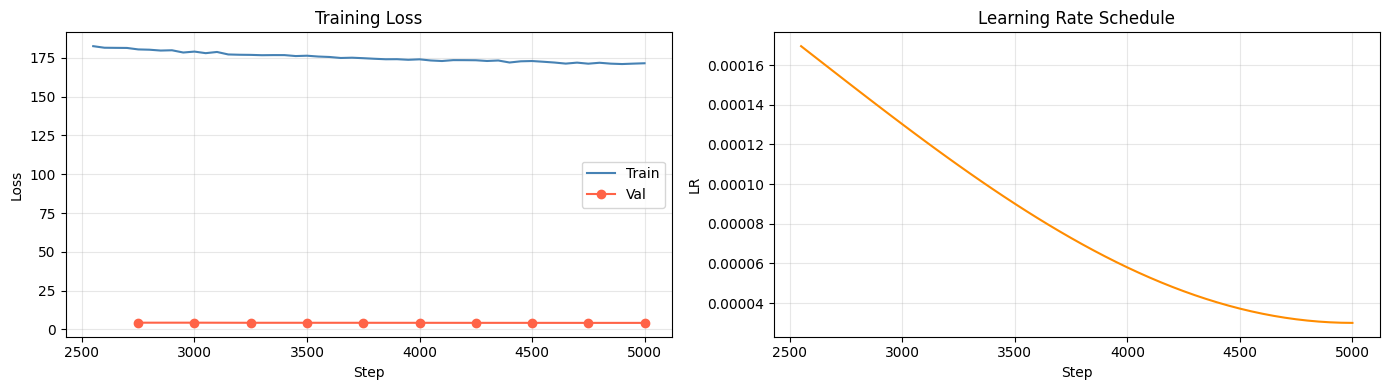

In [21]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history["step"], history["train_loss"], color="steelblue", lw=1.5, label="Train")
if history["val_loss"]:
    val_steps  = [v[0] for v in history["val_loss"]]
    val_losses = [v[1] for v in history["val_loss"]]
    ax1.plot(val_steps, val_losses, "o-", color="tomato", lw=1.5, label="Val")
ax1.set_xlabel("Step"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.set_title("Training Loss"); ax1.grid(alpha=0.3)

ax2.plot(history["step"], history["lr"], color="darkorange", lw=1.5)
ax2.set_xlabel("Step"); ax2.set_ylabel("LR")
ax2.set_title("Learning Rate Schedule"); ax2.grid(alpha=0.3)

plt.tight_layout()
curve_path = f"{BASE_DIR}/training_curves.png"
plt.savefig(curve_path, dpi=150)
print(f"📈 Curves saved to: {curve_path}")
plt.show()

## 10. Text Generation

In [65]:
def generate_text(
    prompt: str,
    max_new_tokens: int = 50,
    temperature: float  = 1.0,
    top_k: int          = 50,
) -> str:
    model.eval()
    enc     = tokenizer.encode(prompt)
    idx     = torch.tensor([enc.ids], dtype=torch.long).to(DEVICE)
    out_ids = model.generate(idx, max_new_tokens=max_new_tokens,
                             temperature=temperature, top_k=top_k)
    return tokenizer.decode(out_ids[0].tolist())


prompts = [
    "To sacrifice for another is",

]

for prompt in prompts:
    print(f"\nPROMPT: {prompt}")
    print("-" * 50)
    print(generate_text(prompt, max_new_tokens=150, temperature=0.8, top_k=40))


PROMPT: To sacrifice for another is
--------------------------------------------------
 To sacrifice for another is a desire for the good, but this is not all good for us (Anscombe 1958, 242–251).


## 11. Drive File Summary

In [ ]:
# Show everything saved in your PhiloBot Drive folder
print(f"📁 Contents of {BASE_DIR}:\n")
for root, dirs, files in os.walk(BASE_DIR):
    level = root.replace(BASE_DIR, '').count(os.sep)
    indent = '  ' * level
    folder = os.path.basename(root)
    print(f"{indent}📂 {folder}/")
    sub_indent = '  ' * (level + 1)
    for file in sorted(files):
        size_mb = os.path.getsize(os.path.join(root, file)) / 1e6
        print(f"{sub_indent}📄 {file}  ({size_mb:.1f} MB)")